# Phase 2 Step 2 — Segmentation clustering experiments

This notebook performs the first clustering experiment at the frozen `2017-09-30 23:59:59` household snapshot. It uses no future behavior or return-risk outcome. Selection follows the predeclared order: stability, separation, non-pathological sizes, interpretability, and operational simplicity.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
from sklearn.decomposition import PCA
from marketmind.segmentation.snapshot import build_household_snapshot
from marketmind.segmentation.preprocessing import FINAL_FEATURES, LOG1P_FEATURES, prepare_features
from marketmind.segmentation.evaluation import evaluate_kmeans, evaluate_gmm, seed_stability, cluster_profile
RAW = ROOT / 'data' / 'raw' / 'complete_journey'
FIGURES = ROOT / 'reports' / 'segmentation' / 'figures'
ARTIFACTS = ROOT / 'reports' / 'segmentation' / 'artifacts'
FIGURES.mkdir(parents=True, exist_ok=True); ARTIFACTS.mkdir(parents=True, exist_ok=True)

## Frozen snapshot and feature preparation
One row is one grocery-retail household. Eligibility and features are reconstructed through T only. The nine features were frozen before viewing clustering metrics: two value, two engagement, two diversity, two promotion, and one brand-tendency feature.

In [2]:
transactions = pyreadr.read_r(str(RAW / 'transactions.rds'))[None]
products = pyreadr.read_r(str(RAW / 'products.rda'))['products']
snapshot = build_household_snapshot(transactions, products, snapshot_at='2017-09-30 23:59:59')
assert snapshot.features.shape[0] == snapshot.features.index.nunique() == 2247
assert snapshot.eligibility.eligible_households == 2247
assert not snapshot.features.loc[:, FINAL_FEATURES].isna().any().any()
assert transactions.loc[transactions.transaction_timestamp <= pd.Timestamp('2017-09-30 23:59:59'), 'transaction_timestamp'].max() <= pd.Timestamp('2017-09-30 23:59:59')
prepared = prepare_features(snapshot.features)
X = prepared.scaled
print(snapshot.eligibility)
print('Final features:', FINAL_FEATURES)
print('log1p:', LOG1P_FEATURES, '| unchanged: bounded ratios and unique_departments')

EligibilityAudit(observed_households=2446, excluded_insufficient_history=52, excluded_insufficient_baskets=144, excluded_insufficient_active_span=3, eligible_households=2247)
Final features: ('recency_days', 'basket_frequency', 'monetary_value', 'avg_basket_value', 'unique_departments', 'department_spend_hhi', 'discount_share_of_gross', 'coupon_basket_rate', 'private_label_spend_share')
log1p: ('recency_days', 'basket_frequency', 'monetary_value', 'avg_basket_value') | unchanged: bounded ratios and unique_departments


## Redundancy control, transformations, scaling, and outliers
Excluded before comparison: `active_days` and median cadence duplicate frequency; `active_span_days` is boundary-compressed and partly an eligibility/tenure measure; `unique_products` tracks monetary value too closely; discounted-basket rate duplicates discount intensity and has ceiling mass; dominant-store share has weak behavioral interpretation; median basket value was not needed beside average basket value. `log1p` is applied to recency, frequency, monetary value, and average basket value. Ratios and nearly symmetric department breadth remain unchanged. RobustScaler is frozen because legitimate heavy shoppers remain in scope.

In [3]:
outlier_columns = ['basket_frequency','monetary_value','avg_basket_value','active_span_days','unique_products','unique_departments']
outlier_audit = snapshot.features[outlier_columns].agg(['min','median','max']).T
outlier_audit['max_over_p99'] = snapshot.features[outlier_columns].max() / snapshot.features[outlier_columns].quantile(.99)
display(outlier_audit)
assert not transactions.duplicated().any()
assert not transactions.duplicated(['basket_id','product_id']).any()

,min,median,max,max_over_p99
basket_frequency,5.000000,36.000000,730.000000,2.775665
monetary_value,19.130000,1010.840000,17939.630000,2.462823
avg_basket_value,2.455587,26.988889,196.093056,1.869441
active_span_days,42.000000,259.000000,272.000000,1.000000
unique_products,2.000000,237.000000,1661.000000,1.507451
unique_departments,2.000000,11.000000,20.000000,1.111111


## Candidate algorithms, K range, internal validation, and stability
Only KMeans and full-covariance GaussianMixture are evaluated for K=2..8. Base fits use random state 42. Stability is the mean/min/max of all 45 pairwise ARIs across ten deterministic seed refits; ARI is invariant to label permutation. GMM responsibilities are mixture-model assignment quantities, not customer confidence.

In [4]:
rows, fitted = [], {}
for algorithm in ('kmeans','gmm'):
    for k in range(2,9):
        model, labels, result = (evaluate_kmeans(X,k) if algorithm == 'kmeans' else evaluate_gmm(X,k))
        stability = seed_stability(X, algorithm=algorithm, k=k)
        fitted[(algorithm,k)] = (model, labels)
        rows.append({'algorithm':algorithm,'k':k, **{a:b for a,b in result.items() if a not in ('counts','shares')}, **stability, 'counts':json.dumps(result['counts']), 'shares':json.dumps(result['shares'])})
metrics = pd.DataFrame(rows)
metrics.to_csv(ARTIFACTS / 'clustering_metrics.csv', index=False)
display(metrics)

,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,inertia,distance_median,distance_p95,min_share,ari_mean,ari_min,ari_max,counts,shares,bic,aic,max_responsibility_median,max_responsibility_p10,low_responsibility_share,assignment_entropy_mean
0,kmeans,2,0.193081,1.812854,581.096271,9736.049321,1.765791,3.366896,0.457054,0.993211,0.987572,1.000000,"{""0"": 1027, ""1"": 1220}","{""0"": 0.45705384957721407, ""1"": 0.542946150422...",NaN,NaN,NaN,NaN,NaN,NaN
1,kmeans,3,0.203128,1.564733,559.685496,8177.137364,1.688055,2.898000,0.130396,0.993776,0.988077,1.000000,"{""0"": 293, ""1"": 1077, ""2"": 877}","{""0"": 0.1303960836671117, ""1"": 0.4793057409879...",NaN,NaN,NaN,NaN,NaN,NaN
2,kmeans,4,0.138214,1.830135,466.335558,7548.171360,1.626195,2.784501,0.105474,0.986428,0.952815,1.000000,"{""0"": 758, ""1"": 504, ""2"": 748, ""3"": 237}","{""0"": 0.3373386737872719, ""1"": 0.2242990654205...",NaN,NaN,NaN,NaN,NaN,NaN
3,kmeans,5,0.132547,1.883463,414.030513,7049.110267,1.558343,2.709724,0.093458,0.875989,0.764970,1.000000,"{""0"": 636, ""1"": 485, ""2"": 210, ""3"": 607, ""4"": ...","{""0"": 0.28304405874499333, ""1"": 0.215843346684...",NaN,NaN,NaN,NaN,NaN,NaN
4,kmeans,6,0.136039,1.722309,380.719861,6626.947671,1.515811,2.631323,0.084557,0.942552,0.843791,0.999001,"{""0"": 388, ""1"": 394, ""2"": 541, ""3"": 190, ""4"": ...","{""0"": 0.17267467734757455, ""1"": 0.175344904316...",NaN,NaN,NaN,NaN,NaN,NaN
5,kmeans,7,0.127956,1.713470,352.664350,6302.548865,1.480677,2.548978,0.069871,0.903946,0.708826,1.000000,"{""0"": 157, ""1"": 453, ""2"": 283, ""3"": 459, ""4"": ...","{""0"": 0.06987093902981753, ""1"": 0.201602136181...",NaN,NaN,NaN,NaN,NaN,NaN
6,kmeans,8,0.124920,1.681788,329.937686,6032.995721,1.456152,2.495760,0.029818,0.762191,0.618706,0.967444,"{""0"": 360, ""1"": 398, ""2"": 309, ""3"": 223, ""4"": ...","{""0"": 0.1602136181575434, ""1"": 0.1771250556297...",NaN,NaN,NaN,NaN,NaN,NaN
7,gmm,2,0.173093,NaN,NaN,NaN,NaN,NaN,0.317757,0.999154,0.998188,1.000000,"{""0"": 1533, ""1"": 714}","{""0"": 0.6822429906542056, ""1"": 0.3177570093457...",21100.554434,20477.363145,0.989533,0.808558,0.028482,0.145782
8,gmm,3,0.098892,NaN,NaN,NaN,NaN,NaN,0.215398,0.999434,0.998788,1.000000,"{""0"": 484, ""1"": 917, ""2"": 846}","{""0"": 0.21539830885625277, ""1"": 0.408099688473...",11277.035510,10339.389901,0.996433,0.908298,0.013351,0.089260
9,gmm,4,0.114705,NaN,NaN,NaN,NaN,NaN,0.057410,0.916239,0.717937,0.998598,"{""0"": 129, ""1"": 890, ""2"": 825, ""3"": 403}","{""0"": 0.05740987983978638, ""1"": 0.396083667111...",10663.888859,9411.788930,0.997976,0.874411,0.026257,0.103962


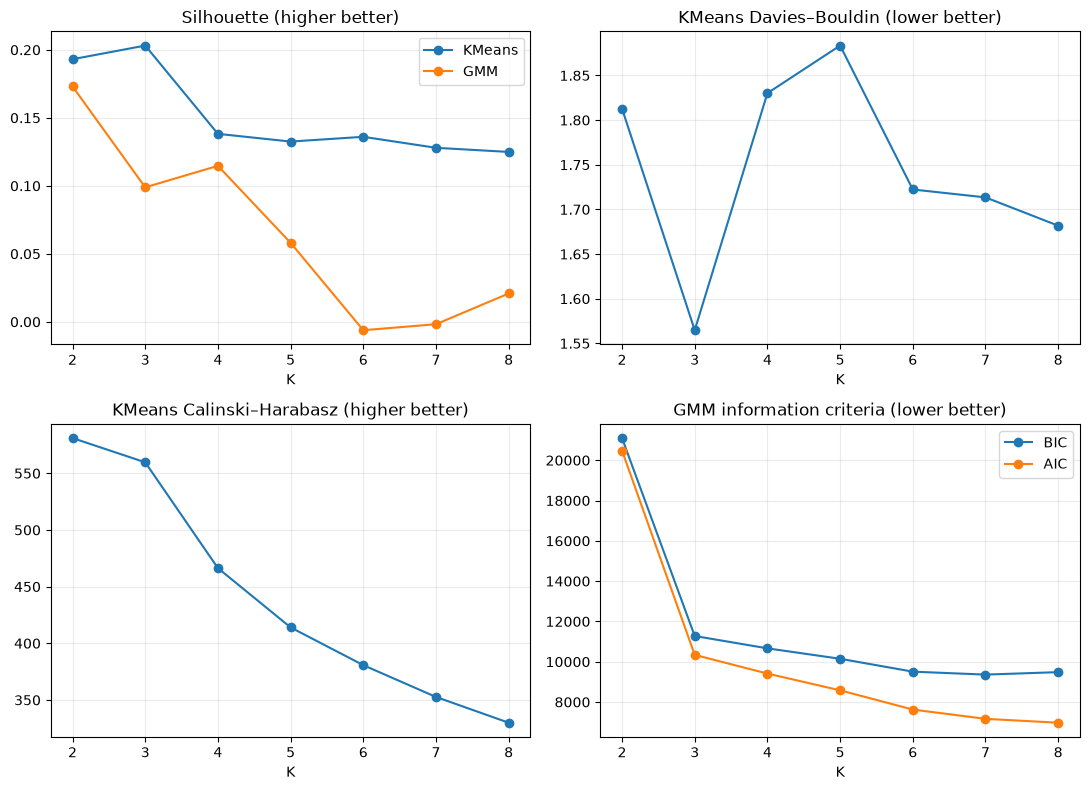

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11,8))
km = metrics.query("algorithm == 'kmeans'"); gm = metrics.query("algorithm == 'gmm'")
axes[0,0].plot(km.k, km.silhouette, marker='o', label='KMeans'); axes[0,0].plot(gm.k, gm.silhouette, marker='o', label='GMM'); axes[0,0].set_title('Silhouette (higher better)'); axes[0,0].legend()
axes[0,1].plot(km.k, km.davies_bouldin, marker='o'); axes[0,1].set_title('KMeans Davies–Bouldin (lower better)')
axes[1,0].plot(km.k, km.calinski_harabasz, marker='o'); axes[1,0].set_title('KMeans Calinski–Harabasz (higher better)')
ax2=axes[1,1]; ax2.plot(gm.k, gm.bic, marker='o', label='BIC'); ax2.plot(gm.k, gm.aic, marker='o', label='AIC'); ax2.set_title('GMM information criteria (lower better)'); ax2.legend()
for ax in axes.flat: ax.set_xlabel('K'); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES/'clustering_metrics_by_k.png', dpi=160); plt.show()

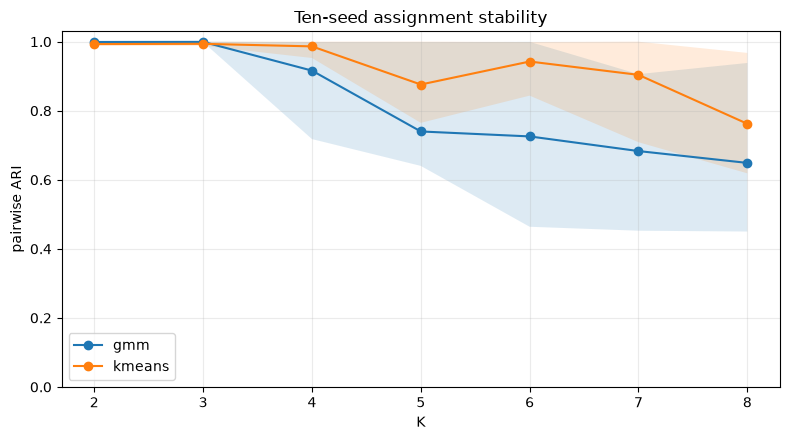

In [6]:
fig, ax = plt.subplots(figsize=(8,4.5))
for algorithm, group in metrics.groupby('algorithm'): ax.plot(group.k, group.ari_mean, marker='o', label=algorithm); ax.fill_between(group.k, group.ari_min, group.ari_max, alpha=.15)
ax.set(xlabel='K', ylabel='pairwise ARI', title='Ten-seed assignment stability'); ax.set_ylim(0,1.03); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/'clustering_stability_by_k.png', dpi=160); plt.show()

## Candidate profiles and decision
KMeans-3 and GMM-3 are profiled because both are highly seed-stable and avoid tiny groups. KMeans-3 is selected under the predeclared policy: it has materially stronger separation than GMM-3, non-pathological sizes, neutral interpretable profiles, and the simpler operational contract. Higher-K GMM fits improve AIC/BIC but lose separation and stability; higher-K KMeans fits also reduce separation and eventually create a 3% group.

In [7]:
profile_columns = ['recency_days','basket_frequency','monetary_value','avg_basket_value','unique_products','unique_departments','department_spend_hhi','discount_share_of_gross','discounted_basket_rate','coupon_basket_rate','private_label_spend_share','dominant_store_basket_share']
profiles = {}
for algorithm in ('kmeans','gmm'):
    labels = fitted[(algorithm,3)][1]
    profiles[algorithm] = cluster_profile(snapshot.features[profile_columns], labels)
    profiles[algorithm].to_csv(ARTIFACTS/f'{algorithm}_k3_profiles.csv')
    print(algorithm.upper(), 'K=3 original-unit medians'); display(profiles[algorithm])

KMEANS K=3 original-unit medians


,household_count,household_share,recency_days,basket_frequency,monetary_value,avg_basket_value,unique_products,unique_departments,department_spend_hhi,discount_share_of_gross,discounted_basket_rate,coupon_basket_rate,private_label_spend_share,dominant_store_basket_share
cluster,,,,,,,,,,,,,,
0,293,0.130396,5.0,34.0,1412.95,43.322500,323.0,11.0,0.348738,0.194658,0.923077,0.214286,0.239595,0.847826
1,1077,0.479306,2.0,61.0,1830.30,30.008165,380.0,13.0,0.308747,0.140954,0.861702,0.032000,0.278938,0.766234
2,877,0.390298,13.0,17.0,378.33,19.651930,99.0,8.0,0.375787,0.150057,0.833333,0.000000,0.259194,0.750000


GMM K=3 original-unit medians


,household_count,household_share,recency_days,basket_frequency,monetary_value,avg_basket_value,unique_products,unique_departments,department_spend_hhi,discount_share_of_gross,discounted_basket_rate,coupon_basket_rate,private_label_spend_share,dominant_store_basket_share
cluster,,,,,,,,,,,,,,
0,484,0.215398,6.0,27.0,886.060,31.391587,221.0,11.0,0.350381,0.174870,0.888889,0.142857,0.248642,0.822401
1,917,0.408100,3.0,57.0,1806.020,30.271935,379.0,13.0,0.322707,0.153239,0.875000,0.047619,0.280731,0.766234
2,846,0.376502,9.0,19.0,461.625,21.381401,121.0,8.0,0.349791,0.135564,0.833333,0.000000,0.250872,0.747727


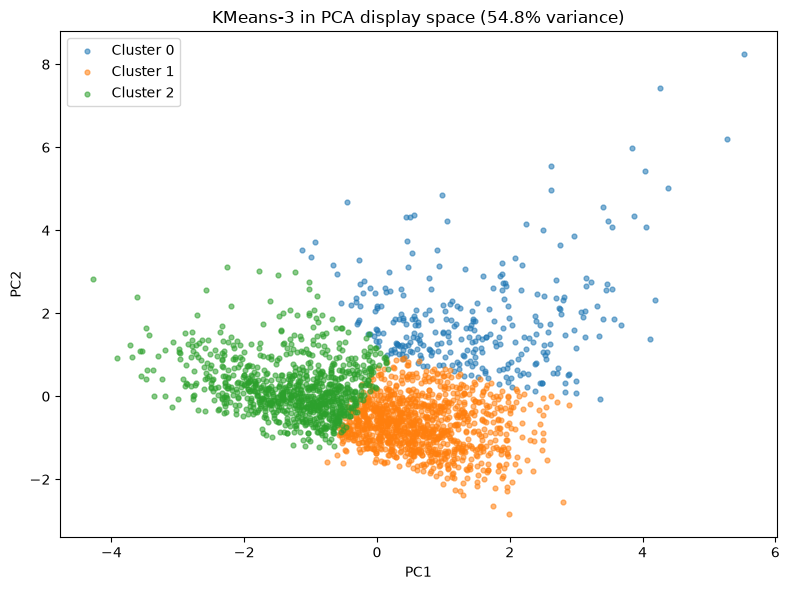

PCA explained variance ratios: [0.32093439 0.2265971 ]


In [8]:
labels = fitted[('kmeans',3)][1]
pca = PCA(n_components=2).fit(X)
scores = pca.transform(X)
fig, ax = plt.subplots(figsize=(8,6))
for cluster in np.unique(labels):
    mask=labels==cluster; ax.scatter(scores[mask,0],scores[mask,1],s=12,alpha=.55,label=f'Cluster {cluster}')
ax.set(title=f'KMeans-3 in PCA display space ({pca.explained_variance_ratio_.sum():.1%} variance)',xlabel='PC1',ylabel='PC2'); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/'kmeans_k3_pca.png',dpi=160); plt.show()
print('PCA explained variance ratios:', pca.explained_variance_ratio_)

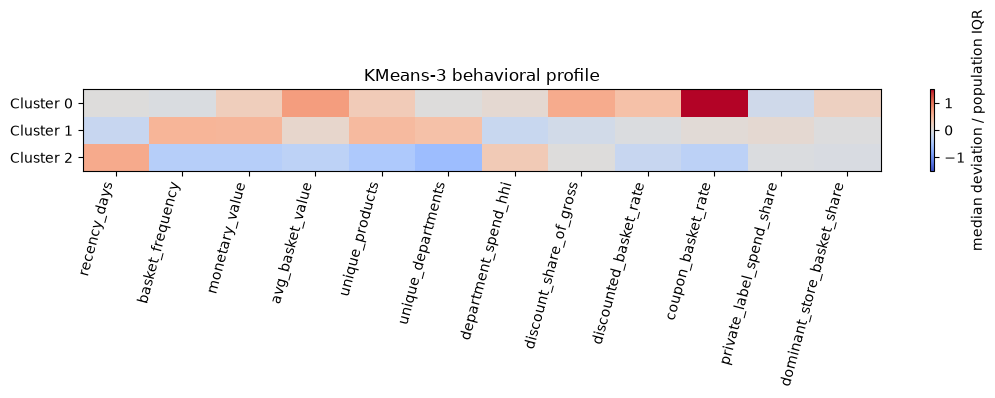

In [9]:
median_matrix = profiles['kmeans'].drop(columns=['household_count','household_share'])
normalized = (median_matrix - snapshot.features[median_matrix.columns].median()) / snapshot.features[median_matrix.columns].apply(lambda s: s.quantile(.75)-s.quantile(.25))
fig, ax = plt.subplots(figsize=(11,3.5)); image=ax.imshow(normalized,cmap='coolwarm',vmin=-1.5,vmax=1.5,aspect='auto'); ax.set_xticks(range(len(normalized.columns)),normalized.columns,rotation=75,ha='right'); ax.set_yticks(range(3),[f'Cluster {i}' for i in normalized.index]); fig.colorbar(image,ax=ax,label='median deviation / population IQR'); ax.set_title('KMeans-3 behavioral profile'); fig.tight_layout(); fig.savefig(FIGURES/'kmeans_k3_profile_heatmap.png',dpi=160); plt.show()

## Interpretation boundary
Clusters are described only by observed behavior; polished segment names remain deferred. KMeans distance is an atypicality measure in scaled feature space, not a probability. GMM maximum responsibility is assignment ambiguity under the fitted mixture assumptions, not customer confidence. The methodology is ready for naming review, but neither productionization nor Customer Return Risk begins here.